# AFM Simulation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.optimize import curve_fit
from typing import Tuple, Optional

We implement different processors as different classes. We will seperate the cantilever, the contact mechanics and the spatial structure.

## Cantilever 
This class will give us the power spectral density (PSD) for a choosen cantilever. The user must input the spring constant $k$, the resonant frequency $f_0$ and the quality factor $Q$. These information is provided by the producer. Also, the temperature $T$ that will be used during the experiments must be indicated.
These information will be used to calculate the thermal noise and to calculate the forces in our system. 

In [3]:
class AFMCantilever:
    def __init__(self, 
                 k: float = 0.5,  # Spring constant [N/m]
                 f0: float = 75e3,  # Resonance frequency [Hz]
                 Q: float = 100,  # Quality factor
                 T: float = 300):  # Temperature [K]

        self.k = k
        self.f0 = f0
        self.Q = Q
        self.T = T
        self.kB = 1.380649e-23  # Boltzmann constant [J/K]
        
        self.m_eff = k / (2 * np.pi * f0)**2
        
        self.gamma = 2 * np.pi * f0 * self.m_eff / Q
        
    def thermal_noise_rms(self) -> float:
        return np.sqrt(self.kB * self.T / self.k)
    
    def thermal_noise_psd_theoretical(self, f: np.ndarray) -> np.ndarray:
        omega = 2 * np.pi * f
        omega0 = 2 * np.pi * self.f0
        
        denominator = (omega0**2 - omega**2)**2 + (omega * omega0 / self.Q)**2
        S_x = (4 * self.kB * self.T * self.gamma) / (self.k**2 * denominator)
        
        return S_x

    # def thermal_noise_psd_experimental(self, path: string) -> np.ndarray:
        
    #     return S_x

    def generate_thermal_noise(self, n_points: int, fs: float, type: str) -> np.ndarray:

        dt = 1/fs
        freqs = np.fft.rfftfreq(n_points, dt)

        if type == "Theoretical":
            psd = self.thermal_noise_psd_theoretical(freqs)
        elif type == "Experimental":
            psd = self.thermal_noise_psd_experimental(path)
        
        amplitudes = np.sqrt(psd * fs / 2)
        phase = np.random.uniform(0, 2*np.pi, len(freqs))
        fourier_coeffs = amplitudes * np.exp(1j * phase)
        
        fourier_coeffs[0] = np.abs(fourier_coeffs[0])
        
        noise = np.fft.irfft(fourier_coeffs, n_points)
        
        return noise

## Contact Mechanics
The contact mechanics that will be used to analyze the interaction between the cantilever and the sample must be selected by the user. Here we provide an exemple using the Hertz contact mechanics. 

In [4]:
class HertzContact:
    def __init__(self, 
                 R: float = 10e-9,  # Tip radius [m]
                 E: float = 130e9,  # Young's modulus [Pa] 
                 nu: float = 0.5):  # Poisson ratio of sample
        self.R = R
        self.E = E
        self.nu = nu

    def force(self, cantilever_shape: str, indentation: np.ndarray, contact_point:float) -> np.ndarray:
        indentation += contact_point
        ind = np.maximum(indentation, 0)

        if cantilever_shape == "Sphere":
            return (4/3) * self.E * np.sqrt(self.R) * ind**(3/2) / (1 - self.nu**2)


## Sample properties
Type of sample must be defined by the user. The expected forms and height ranges as well as expected stiffness values must be provided. Here we offer two exemples. One, a circular shape that can be used to illustrate cells. Second, gaussian features that can be use to illustrate tissue samples.

In [5]:
class Sample:

    def __init__(self, 
                 E_substrate= 20e3, 
                 E_sample= 2e3,
                 Height_range = [0,5e-6]):
        self.E_substrate = E_substrate
        self.E_sample = E_sample
        self.Height_range = Height_range
        
    def create_topography(self, 
                         size: Tuple[int, int] = (128, 128),
                         pixel_size: float = 1e-6,
                         topography_type: str = 'gaussian_features') -> np.ndarray:
        ny, nx = size
        
        if topography_type == 'gaussian_features':
            topo = np.zeros((ny, nx))
            n_features = 10
            
            for _ in range(n_features):
                cx = np.random.randint(0, nx)
                cy = np.random.randint(0, ny)
                
                amplitude = np.random.uniform(min(self.Height_range), max(self.Height_range))
                sigma = np.random.uniform(5, 15)
                
                y, x = np.ogrid[0:ny, 0:nx]
                gaussian = amplitude * np.exp(-((x-cx)**2 + (y-cy)**2) / (2*sigma**2))
                topo += gaussian

        elif topography_type == 'hemisphere':
                radius = max(self.Height_range)
                x = np.linspace(-1, 1, nx)
                y = np.linspace(-1, 1, ny)
                X, Y = np.meshgrid(x, y)
            
                R = np.sqrt(X**2 + Y**2)
                topo = np.zeros_like(R)
            
                mask = R <= radius
                topo[mask] = max(self.Height_range) * (1 - (R[mask] / radius)**2)
            
        return topo

## The Simulator

In [39]:
class AFMSimulator:

    def __init__(self, cantilever: AFMCantilever, contact_model: HertzContact, sample: Sample):
        self.cantilever = cantilever
        self.contact_model = contact_model
        self.sample = sample
        
    def simulate_fdc(self, 
                    z_length: float = 10**6,
                    setpoint_force: float = 1e-9,
                    f: int = 2048, 
                    height: float = 2e-6,
                    approach_rate: float = 2, # um/s
                    include_thermal_noise: bool = True) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:

        total_distance = z_length
        total_time = total_distance / (approach_rate * 1e-6)
        n_points = int(total_time * f)
        dt = 1/f
        
        z_piezo = np.concatenate([
            np.linspace(0, z_length, n_points),  # approach
            np.linspace(z_length,0, n_points)   # retract
        ])

        max_indentation = (setpoint_force / ((4/3) * self.contact_model.E * 
                                     np.sqrt(self.contact_model.R)))**(2/3)

        indentation = -z_piezo  
        
        force = self.contact_model.force("Sphere", indentation, height)

        deflection = force / self.cantilever.k

        if include_thermal_noise:
            # thermal_noise = self.cantilever.generate_thermal_noise(len(z_piezo), dt)
            sigma = self.cantilever.thermal_noise_rms()
            thermal_noise = np.random.normal(0, sigma, size=len(deflection))
            deflection += thermal_noise
            force = deflection * self.cantilever.k
        
        return z_piezo, deflection, force

    

## Necessary function for visualisation

In [7]:
def create_visualizations(topography, height_map,
                         z_piezo, deflection, force, cantilever, contact):

    fig = plt.figure(figsize=(18, 12))
    
    # 1. True topography
    ax1 = fig.add_subplot(2, 2, 1)
    im1 = ax1.imshow(topography, cmap='viridis', aspect='equal')
    ax1.set_title('True Topography', fontsize=12, fontweight='bold')
    ax1.set_xlabel('X [pixels]')
    ax1.set_ylabel('Y [pixels]')
    plt.colorbar(im1, ax=ax1, label='Height [m]')

    
    # 2. Force-distance curve - an example
    ax2 = fig.add_subplot(2, 2, 2)
    n_half = len(z_piezo) // 2
    ax2.plot(z_piezo[:n_half], force[:n_half], 'b-', label='Approach', linewidth=1.5)
    ax2.plot(z_piezo[n_half:], force[n_half:], 'r-', label='Retract', linewidth=1.5, alpha=0.7)
    ax2.set_xlabel('Z Piezo Position [m]')
    ax2.set_ylabel('Force [nN]')
    ax2.set_title('Force-Distance Curve', fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. Thermal noise PSD
    ax3 = fig.add_subplot(2, 2, 3)
    freqs = np.logspace(3, 6, 10000)  # 1 kHz to 1 MHz
    psd = cantilever.thermal_noise_psd(freqs)
    ax3.loglog(freqs / 1e3, np.sqrt(psd), 'b-', linewidth=2)
    ax3.axvline(cantilever.f0 / 1e3, color='r', linestyle='--', label=f'f₀ = {cantilever.f0/1e3:.1f} kHz')
    ax3.set_xlabel('Frequency [kHz]')
    ax3.set_ylabel('Noise Amplitude [m/√Hz]')
    ax3.set_title('Thermal Noise Spectrum', fontsize=12, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3, which='both')
    
    # 4. Noise statistics
    ax4 = fig.add_subplot(2, 2, 4)
    # Generate thermal noise sample
    # noise_sample = cantilever.Langevin(10000, 1/2048    sigma = cantilever.thermal_noise_rms() 
    sigma = cantilever.thermal_noise_rms() 
    noise_sample = np.random.normal(0, sigma, size=len(deflection))
    ax4.hist(noise_sample, bins=50, density=True, alpha=0.7, color='blue', edgecolor='black')
    
    # Overlay theoretical Gaussian
    x_gauss = np.linspace(noise_sample.min(), noise_sample.max(), 100) 
    
    gaussian = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-x_gauss**2 / (2 * sigma**2))
    ax4.plot(x_gauss, gaussian, 'r-', linewidth=2, label=f'Gaussian (σ={sigma} m)')
    
    ax4.set_xlabel('Displacement')
    ax4.set_ylabel('Probability Density')
    ax4.set_title('Thermal Noise Distribution', fontsize=12, fontweight='bold')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('afm_simulation_results.png', dpi=150, bbox_inches='tight')
    print("Saved: afm_simulation_results.png")
    plt.show()

## How to generate data
- First, define cantilever:

In [16]:
cantilever = AFMCantilever(
    k=0.1,      # N/m - soft cantilever for contact mode
    f0=7e3,    # Hz
    Q=100,      # Quality factor in air
    T=30000       # K
)

- Second, define contact mechanics:

In [9]:
contact = HertzContact(
    R=5e-6,    # tip radius
    E=1000,    # Silicon tip
    nu=0.5     # poisson ratio
)

- Third, define sample properties:

In [10]:
sample = Sample(
    E_substrate = 20e3,
    E_sample = 2e3,
    Height_range = [1e-7, 5e-7]
)
topography = sample.create_topography(
        size=(64, 64),
        pixel_size=2e-9,
        topography_type='gaussian_features'
    )

- Create simulator and generate data:

In [40]:
simulator = AFMSimulator(cantilever, contact, sample)

Now we can generate a force curve

In [27]:
z_piezo, deflection, force = simulator.simulate_fdc(
    z_length=10e-6,
    setpoint_force=1e-9,
    f=2048,
    height=1e-6,
    approach_rate=1,
    include_thermal_noise=True
)

[3.97523196e-09 3.97232063e-09 3.96941000e-09 ... 3.96941000e-09
 3.97232063e-09 3.97523196e-09]


And continue for the rest of our topgraphy

In [43]:
# measured_map = np.zeros((topography.shape[0],topography.shape[1]), dtype=np.float64)
rows, cols = topography.shape[0], topography.shape[1]
grid_z_piezo = [[[0,0,0] for _ in range(cols)] for _ in range(rows)]
grid_force = [[[0,0,0] for _ in range(cols)] for _ in range(rows)]

for i in range(topography.shape[0]):
    for j in range(topography.shape[1]):

        height = topography[i,j]

        z_piezo, deflection, force = simulator.simulate_fdc(
            z_length=10e-6,
            setpoint_force=1e-9,
            f=2048,
            height=height,
            approach_rate=1,
            include_thermal_noise=True
        )

 
        grid_z_piezo[i][j] = z_piezo
        grid_force[i][j] = z_piezo

grid_force=np.array(grid_force)
print(grid_force.shape)

(64, 64, 40960)


- Visualize:

Saved: afm_simulation_results.png


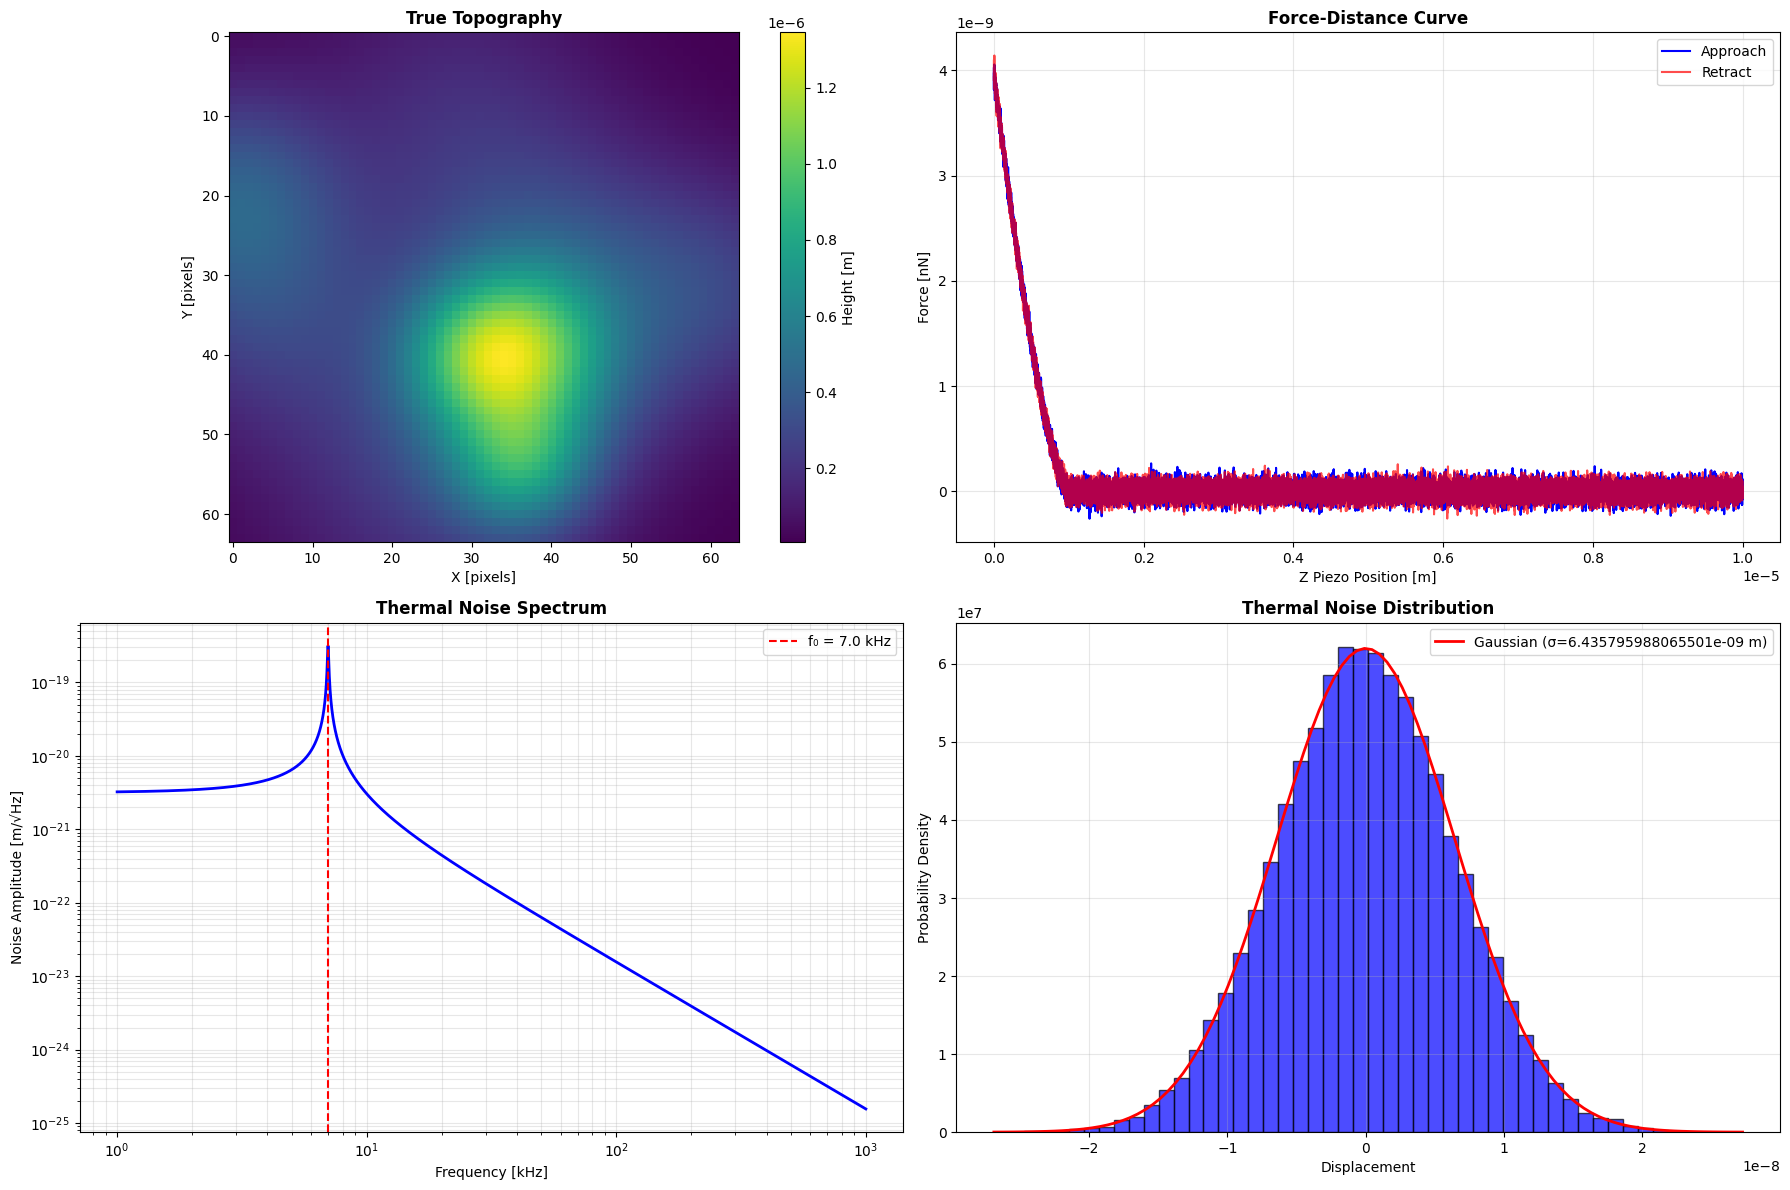

In [67]:
create_visualizations(topography, height_map,
                         z_piezo, deflection, force, cantilever, contact)

## Building our network

In [44]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

In [48]:
# ── E: ML dataset ─────────────────────────────────────────────────────────────
N_CURVES           = 5000            # training + validation curves
E_MIN_KPA          = 0.5
E_MAX_KPA          = 500.0           # log-uniform sampling
CONTACT_OFFSET_STD_NM = 8.0          # std of z_cp draw (nm)
ENABLE_FORCE_NOISE = True
FORCE_NOISE_NN     = 0.3             # nN additive Gaussian noise

# ── F: CNN architecture ───────────────────────────────────────────────────────
CNN_CHANNELS       = [32, 64, 128, 256]   # conv layer output channels
CNN_KERNEL_SIZE    = 7
CNN_FC_HIDDEN      = 128
DROPOUT_RATE       = 0.3

# ── G: Training ───────────────────────────────────────────────────────────────
BATCH_SIZE         = 128
N_EPOCHS           = 80
LEARNING_RATE      = 3e-4
WEIGHT_DECAY       = 1e-4
VALIDATION_FRAC    = 0.15
TEST_FRAC          = 0.15
LOSS_WEIGHT_E      = 1.0             # weight on MAPE_E term
LOSS_WEIGHT_CP     = 0.5             # weight on MAE_cp term (different scale)
RANDOM_SEED        = 42

# ── H: 2-D prediction map ────────────────────────────────────────────────────
MAP_NX, MAP_NY     = 64, 64          # pixel grid
MAP_PIXEL_NM       = 8.0             # nm / pixel
E_SOFT_KPA         = 5.0             # Young's modulus inside soft inclusion
E_STIFF_KPA        = 150.0           # Young's modulus in background
INCLUSION_FRAC     = 0.28            # inclusion radius / half-grid width
CP_OFFSET_SOFT_NM  = 5.0            # contact-point offset in soft region
CP_OFFSET_STIFF_NM = -5.0           # contact-point offset in stiff region

# ── I: Output ─────────────────────────────────────────────────────────────────
SHOW_EXAMPLE_CURVES = True
SHOW_TRAINING_CURVE = True
SHOW_EVAL_PLOTS     = True
SHOW_PREDICTION_MAP = True
EXPORT              = True
EXPORT_PREFIX       = "afm_v6"

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
z = grid_z_piezo[0][0]
N_CURVE_PTS = len(z)
print(f"Force-curve length: {N_CURVE_PTS} pts  ({N_CURVE_PTS/2} pre + {N_CURVE_PTS/2} contact)")
print(f"Dataset: {topography.shape[0]**2} curves  |  E=[{E_MIN_KPA},{E_MAX_KPA}] kPa  |  map: {MAP_NX}×{MAP_NY}")

Force-curve length: 40960 pts  (20480.0 pre + 20480.0 contact)
Dataset: 4096 curves  |  E=[0.5,500.0] kPa  |  map: 64×64


### Pre-Proessing of simulated data
We first have to normalize the simulated dataset.

In [52]:
def normalize_curve(z_nm: np.ndarray, F_nN: np.ndarray) -> np.ndarray:
    """
    Return 2 × N_CURVE_PTS array with channels:
      ch0: z_piezo normalised to [0, 1] by range
      ch1: force    normalised to [0, 1] by max positive value
    """
    z_n = (z_nm - z_nm.min()) / (z_nm.max() - z_nm.min() + 1e-12)
    f_max = np.maximum(F_nN, 0.0).max()
    f_n   = np.clip(F_nN, 0.0, None) / (f_max + 1e-12)
    return np.stack([z_n, f_n], axis=0).astype(np.float32)   # (2, N)

print("Simulator functions defined.")

data = []

for i in range(64):
    for j in range(64):
        normalized = normalize_curve(grid_z_piezo[i][j], grid_force[i][j])
        data.append(normalized)

print(normalized.shape)
data=np.array(data)
print(data.shape)

Simulator functions defined.
(2, 40960)
(4096, 2, 40960)


In [65]:
class CurveDataset(Dataset):
    def __init__(self, X, y_logE, y_cp):
        self.X     = torch.from_numpy(X)
        self.y_logE = torch.from_numpy(y_logE).unsqueeze(1)
        self.y_cp   = torch.from_numpy(y_cp).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y_logE[idx], self.y_cp[idx]

full_ds = CurveDataset(data[:,0,:], data[:,1,:],data[:,1,:])

n_total = len(full_ds)
n_test  = int(n_total * TEST_FRAC)
n_val   = int(n_total * VALIDATION_FRAC)
n_train = n_total - n_val - n_test

gen = torch.Generator().manual_seed(RANDOM_SEED)
train_ds, val_ds, test_ds = random_split(full_ds, [n_train, n_val, n_test], generator=gen)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Split — train: {n_train}  val: {n_val}  test: {n_test}")


Split — train: 2868  val: 614  test: 614


In [66]:
class Conv1dBlock(nn.Module):
    """Conv → BN → ReLU → MaxPool."""
    def __init__(self, in_ch, out_ch, kernel, pool=2, dropout=0.0):
        super().__init__()
        pad = kernel // 2
        self.block = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel, padding=pad, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(pool),
            nn.Dropout(dropout) if dropout > 0 else nn.Identity(),
        )
    def forward(self, x):
        return self.block(x)


class ForceCurveCNN(nn.Module):
    """
    Input : (B, 2, N_CURVE_PTS)   — 2-channel normalised approach curve
    Output: (B, 1) log10_E,  (B, 1) z_cp_nm
    """
    def __init__(self, n_pts: int, channels: list, kernel: int,
                 fc_hidden: int, dropout: float):
        super().__init__()
        in_ch = 2
        blocks = []
        for out_ch in channels:
            blocks.append(Conv1dBlock(in_ch, out_ch, kernel, pool=2, dropout=dropout))
            in_ch = out_ch
        self.encoder = nn.Sequential(*blocks)
        self.pool    = nn.AdaptiveAvgPool1d(1)   # global average pool → (B, C, 1)

        self.head_E = nn.Sequential(
            nn.Linear(in_ch, fc_hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(fc_hidden, 1)
        )
        self.head_cp = nn.Sequential(
            nn.Linear(in_ch, fc_hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(fc_hidden, 1)
        )

    def forward(self, x):
        z = self.pool(self.encoder(x)).squeeze(-1)   # (B, C)
        return self.head_E(z), self.head_cp(z)


def mape_loss(y_pred: torch.Tensor, y_true_logE: torch.Tensor) -> torch.Tensor:
    """
    MAPE in linear E space.
    y_pred and y_true are log10(E/kPa); we back-transform to compute percentage error.
    """
    E_pred = 10.0 ** y_pred
    E_true = 10.0 ** y_true_logE
    return torch.mean(torch.abs(E_pred - E_true) / (E_true + 1e-6)) * 100.0


def combined_loss(logE_pred, cp_pred, logE_true, cp_true,
                  w_E=LOSS_WEIGHT_E, w_cp=LOSS_WEIGHT_CP):
    loss_E  = mape_loss(logE_pred, logE_true)
    loss_cp = torch.mean(torch.abs(cp_pred - cp_true))     # MAE in nm
    return w_E * loss_E + w_cp * loss_cp, loss_E.item(), loss_cp.item()


model = ForceCurveCNN(
    n_pts=N_CURVE_PTS,
    channels=CNN_CHANNELS,
    kernel=CNN_KERNEL_SIZE,
    fc_hidden=CNN_FC_HIDDEN,
    dropout=DROPOUT_RATE,
)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTrainable parameters: {n_params:,}")

ForceCurveCNN(
  (encoder): Sequential(
    (0): Conv1dBlock(
      (block): Sequential(
        (0): Conv1d(2, 32, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
        (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (4): Dropout(p=0.3, inplace=False)
      )
    )
    (1): Conv1dBlock(
      (block): Sequential(
        (0): Conv1d(32, 64, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (4): Dropout(p=0.3, inplace=False)
      )
    )
    (2): Conv1dBlock(
      (block): Sequential(
        (0): Conv1d(64, 128, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
        (1): Batch

In [69]:
import time

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS, eta_min=1e-6)

history = {"train_loss": [], "val_loss": [],
           "train_mape": [], "val_mape": [],
           "train_mae_cp": [], "val_mae_cp": []}

best_val_loss = float("inf")
best_state    = None

print(f"Training for {N_EPOCHS} epochs")
t_start = time.time()

for epoch in range(1, N_EPOCHS + 1):
    # ── train ──
    model.train()
    tr_loss = tr_mape = tr_mae_cp = 0.0
    for X_b, yE_b, ycp_b in train_loader:
        optimizer.zero_grad()
        pE, pcp = model(X_b)
        loss, mape_e, mae_c = combined_loss(pE, pcp, yE_b, ycp_b)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        tr_loss   += loss.item()
        tr_mape   += mape_e
        tr_mae_cp += mae_c
    scheduler.step()
    n_tr = len(train_loader)
    history["train_loss"].append(tr_loss / n_tr)
    history["train_mape"].append(tr_mape / n_tr)
    history["train_mae_cp"].append(tr_mae_cp / n_tr)

    # ── validate ──
    model.eval()
    vl_loss = vl_mape = vl_mae_cp = 0.0
    with torch.no_grad():
        for X_b, yE_b, ycp_b in val_loader:
            pE, pcp = model(X_b)
            loss, mape_e, mae_c = combined_loss(pE, pcp, yE_b, ycp_b)
            vl_loss   += loss.item()
            vl_mape   += mape_e
            vl_mae_cp += mae_c
    n_vl = len(val_loader)
    history["val_loss"].append(vl_loss / n_vl)
    history["val_mape"].append(vl_mape / n_vl)
    history["val_mae_cp"].append(vl_mae_cp / n_vl)

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if epoch % 10 == 0 or epoch == 1:
        elapsed = time.time() - t_start
        lr_now  = scheduler.get_last_lr()[0]
        print(f"Epoch {epoch:3d}/{N_EPOCHS}  "
              f"train_loss={history['train_loss'][-1]:.3f}  "
              f"val_loss={history['val_loss'][-1]:.3f}  "
              f"MAPE_E={history['val_mape'][-1]:.1f}%  "
              f"MAE_cp={history['val_mae_cp'][-1]:.2f}nm  "
              f"lr={lr_now:.2e}  t={elapsed:.0f}s")

# Restore best weights
model.load_state_dict(best_state)
print(f"\nBest val loss: {best_val_loss:.4f}  (weights restored)")

Training for 80 epochs


RuntimeError: Given groups=1, weight of size [32, 2, 7], expected input[1, 128, 40960] to have 2 channels, but got 128 channels instead

ValueError: x and y must have same first dimension, but have shapes (80,) and (0,)

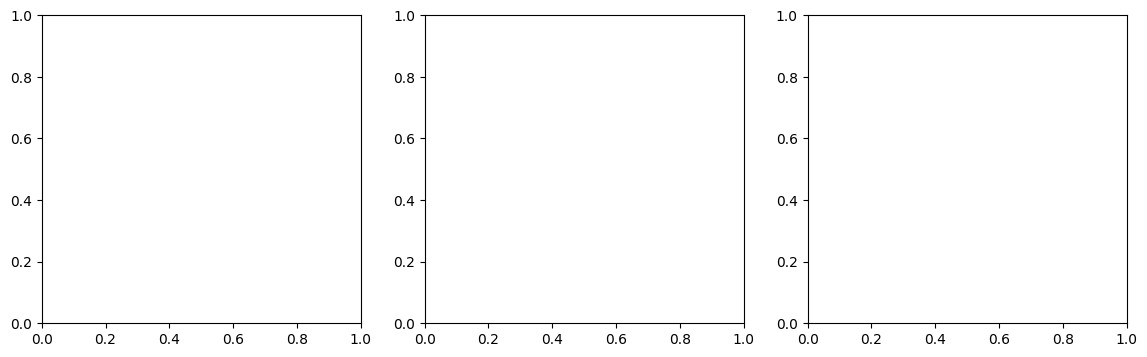

In [70]:
if SHOW_TRAINING_CURVE:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    epochs = range(1, N_EPOCHS + 1)

    axes[0].plot(epochs, history["train_loss"], label="train")
    axes[0].plot(epochs, history["val_loss"],   label="val")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Combined loss")
    axes[0].set_title("Total loss  (w_E × MAPE + w_cp × MAE)")
    axes[0].legend()

    axes[1].plot(epochs, history["train_mape"], label="train")
    axes[1].plot(epochs, history["val_mape"],   label="val")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MAPE (%)")
    axes[1].set_title("MAPE — Young's modulus (linear kPa space)")
    axes[1].legend()

    axes[2].plot(epochs, history["train_mae_cp"], label="train")
    axes[2].plot(epochs, history["val_mae_cp"],   label="val")
    axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("MAE (nm)")
    axes[2].set_title("MAE — contact point")
    axes[2].legend()

    plt.tight_layout(); plt.show()

In [56]:
model.eval()
all_logE_true, all_logE_pred = [], []
all_cp_true,   all_cp_pred   = [], []

with torch.no_grad():
    for X_b, yE_b, ycp_b in test_loader:
        X_b = X_b.to(DEVICE)
        pE, pcp = model(X_b)
        all_logE_true.append(yE_b.numpy())
        all_logE_pred.append(pE.cpu().numpy())
        all_cp_true.append(ycp_b.numpy())
        all_cp_pred.append(pcp.cpu().numpy())

logE_true = np.concatenate(all_logE_true).ravel()
logE_pred = np.concatenate(all_logE_pred).ravel()
cp_true   = np.concatenate(all_cp_true).ravel()
cp_pred   = np.concatenate(all_cp_pred).ravel()

E_true_kPa = 10.**logE_true
E_pred_kPa = 10.**logE_pred

mape_test = np.mean(np.abs(E_pred_kPa - E_true_kPa) / (E_true_kPa + 1e-6)) * 100
mdre_test = np.median(np.abs(E_pred_kPa - E_true_kPa) / (E_true_kPa + 1e-6)) * 100
mae_cp    = np.mean(np.abs(cp_pred - cp_true))
r2_E      = 1 - np.sum((logE_true - logE_pred)**2) / (np.sum((logE_true - logE_true.mean())**2) + 1e-12)
r2_cp     = 1 - np.sum((cp_true  - cp_pred )**2)  / (np.sum((cp_true  - cp_true.mean())**2)  + 1e-12)

print("── Young's modulus ───────────────────────────────────────────")
print(f"  R² (log scale)  : {r2_E:.4f}")
print(f"  MAPE (kPa)      : {mape_test:.1f} %")
print(f"  MdRE (kPa)      : {mdre_test:.1f} %")
print("── Contact point ─────────────────────────────────────────────")
print(f"  R²              : {r2_cp:.4f}")
print(f"  MAE             : {mae_cp:.2f} nm")

if SHOW_EVAL_PLOTS:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # 1) E parity – log-log
    ax = axes[0]
    sc = ax.scatter(E_true_kPa, E_pred_kPa,
                    c=np.log10(E_true_kPa), cmap='plasma', s=8, alpha=0.5)
    lims = [E_MIN_KPA * 0.7, E_MAX_KPA * 1.3]
    ax.plot(lims, lims, 'k--', lw=1)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("E_true (kPa)"); ax.set_ylabel("E_pred (kPa)")
    ax.set_title(f"Young's modulus  R²={r2_E:.3f}  MAPE={mape_test:.1f}%")
    plt.colorbar(sc, ax=ax, label="log₁₀(E_true)")

    # 2) cp parity
    ax = axes[1]
    ax.scatter(cp_true, cp_pred, s=8, alpha=0.5, color='teal')
    lim_cp = max(abs(cp_true).max(), abs(cp_pred).max()) * 1.15
    ax.plot([-lim_cp, lim_cp], [-lim_cp, lim_cp], 'k--', lw=1)
    ax.set_xlabel("z_contact_true (nm)"); ax.set_ylabel("z_contact_pred (nm)")
    ax.set_title(f"Contact point  R²={r2_cp:.3f}  MAE={mae_cp:.2f} nm")

    # 3) E residuals vs E_true
    ax = axes[2]
    rel_err = (E_pred_kPa - E_true_kPa) / E_true_kPa * 100
    ax.scatter(E_true_kPa, rel_err, s=6, alpha=0.4, color='coral')
    ax.axhline(0, color='k', lw=1)
    ax.set_xscale('log')
    ax.set_xlabel("E_true (kPa)"); ax.set_ylabel("Relative error (%)")
    ax.set_title("E relative residuals")

    plt.tight_layout(); plt.show()

NameError: name 'model' is not defined

In [57]:
# ── Build ground-truth spatial maps ──────────────────────────────────────────
Y_idx, X_idx = np.mgrid[0:MAP_NY, 0:MAP_NX]
cx, cy = MAP_NX / 2.0, MAP_NY / 2.0
r_norm = np.sqrt((X_idx - cx)**2 + (Y_idx - cy)**2) / (min(MAP_NX, MAP_NY) / 2.0)
in_inclusion = r_norm < INCLUSION_FRAC

E_true_map  = np.where(in_inclusion, E_SOFT_KPA, E_STIFF_KPA).astype(np.float32)
cp_true_map = np.where(in_inclusion, CP_OFFSET_SOFT_NM, CP_OFFSET_STIFF_NM).astype(np.float32)

# ── Generate one force curve per pixel and normalise ─────────────────────────
rng_map = np.random.default_rng(RANDOM_SEED + 999)
X_map = np.zeros((MAP_NY, MAP_NX, 2, N_CURVE_PTS), dtype=np.float32)

print(f"Generating {MAP_NY*MAP_NX} force curves for {MAP_NY}×{MAP_NX} pixel map …", end=" ")
t0 = time.time()
for iy in range(MAP_NY):
    for ix in range(MAP_NX):
        z, F = simulate_approach_curve(
            E_true_map[iy, ix], cp_true_map[iy, ix],
            sim_cfg, tip_cfg, cant_cfg, rng_map)
        X_map[iy, ix] = normalise_curve(z, F)
print(f"done in {time.time()-t0:.1f}s")

# ── Run CNN on the full map ───────────────────────────────────────────────────
X_map_flat = X_map.reshape(-1, 2, N_CURVE_PTS)   # (NY*NX, 2, N)
map_loader = DataLoader(
    torch.utils.data.TensorDataset(torch.from_numpy(X_map_flat)),
    batch_size=256, shuffle=False)

E_pred_flat  = []
cp_pred_flat = []

model.eval()
with torch.no_grad():
    for (batch,) in map_loader:
        pE, pcp = model(batch.to(DEVICE))
        E_pred_flat.append(pE.cpu().numpy())
        cp_pred_flat.append(pcp.cpu().numpy())

E_pred_map  = (10.0 ** np.concatenate(E_pred_flat ).ravel()).reshape(MAP_NY, MAP_NX)
cp_pred_map = np.concatenate(cp_pred_flat).ravel().reshape(MAP_NY, MAP_NX)

print(f"E_pred range : {E_pred_map.min():.1f}–{E_pred_map.max():.1f} kPa")
print(f"cp_pred range: {cp_pred_map.min():.2f}–{cp_pred_map.max():.2f} nm")

# ── Plot: ground truth vs prediction ─────────────────────────────────────────
if SHOW_PREDICTION_MAP:
    fig = plt.figure(figsize=(14, 11))
    gs  = GridSpec(2, 3, figure=fig, wspace=0.35, hspace=0.4)

    extent = [0, MAP_NX * MAP_PIXEL_NM, 0, MAP_NY * MAP_PIXEL_NM]

    # Row 0 – Young's modulus
    vE_min = min(E_true_map.min(), E_pred_map.min())
    vE_max = max(E_true_map.max(), E_pred_map.max())
    norm_E = mcolors.LogNorm(vmin=vE_min, vmax=vE_max)

    ax = fig.add_subplot(gs[0, 0])
    im = ax.imshow(E_true_map, norm=norm_E, cmap='viridis',
                   origin='lower', extent=extent)
    ax.set_title("E  — ground truth (kPa)"); ax.set_xlabel("x (nm)"); ax.set_ylabel("y (nm)")
    plt.colorbar(im, ax=ax, label="E (kPa)")

    ax = fig.add_subplot(gs[0, 1])
    im = ax.imshow(E_pred_map, norm=norm_E, cmap='viridis',
                   origin='lower', extent=extent)
    ax.set_title("E  — CNN prediction (kPa)"); ax.set_xlabel("x (nm)")
    plt.colorbar(im, ax=ax, label="E (kPa)")

    ax = fig.add_subplot(gs[0, 2])
    E_rel_err = (E_pred_map - E_true_map) / E_true_map * 100
    vabs = np.percentile(np.abs(E_rel_err), 95)
    im = ax.imshow(E_rel_err, cmap='RdBu_r', origin='lower', extent=extent,
                   vmin=-vabs, vmax=vabs)
    ax.set_title("E  — relative error (%)"); ax.set_xlabel("x (nm)")
    plt.colorbar(im, ax=ax, label="Rel. error (%)")

    # Row 1 – Contact point
    vcp_abs = max(abs(cp_true_map).max(), abs(cp_pred_map).max()) * 1.05
    norm_cp = mcolors.Normalize(vmin=-vcp_abs, vmax=vcp_abs)

    ax = fig.add_subplot(gs[1, 0])
    im = ax.imshow(cp_true_map, norm=norm_cp, cmap='coolwarm',
                   origin='lower', extent=extent)
    ax.set_title("z_contact — ground truth (nm)"); ax.set_xlabel("x (nm)"); ax.set_ylabel("y (nm)")
    plt.colorbar(im, ax=ax, label="z_cp (nm)")

    ax = fig.add_subplot(gs[1, 1])
    im = ax.imshow(cp_pred_map, norm=norm_cp, cmap='coolwarm',
                   origin='lower', extent=extent)
    ax.set_title("z_contact — CNN prediction (nm)"); ax.set_xlabel("x (nm)")
    plt.colorbar(im, ax=ax, label="z_cp (nm)")

    ax = fig.add_subplot(gs[1, 2])
    cp_abs_err = cp_pred_map - cp_true_map
    vabs_cp = np.percentile(np.abs(cp_abs_err), 95)
    im = ax.imshow(cp_abs_err, cmap='RdBu_r', origin='lower', extent=extent,
                   vmin=-vabs_cp, vmax=vabs_cp)
    ax.set_title("z_contact — absolute error (nm)"); ax.set_xlabel("x (nm)")
    plt.colorbar(im, ax=ax, label="Abs. error (nm)")

    plt.suptitle(f"2-D CNN Prediction Maps  ({MAP_NY}×{MAP_NX} pixels, 1 curve/px)",
                 fontsize=13, y=1.01)
    plt.show()

Generating 4096 force curves for 64×64 pixel map … 

NameError: name 'time' is not defined

In [ ]:
if EXPORT:
    px = EXPORT_PREFIX
    np.save(f"{px}_X_raw.npy",        X_raw)
    np.save(f"{px}_y_logE.npy",       y_logE)
    np.save(f"{px}_y_cp.npy",         y_cp)
    np.save(f"{px}_E_true_map.npy",   E_true_map)
    np.save(f"{px}_cp_true_map.npy",  cp_true_map)
    np.save(f"{px}_E_pred_map.npy",   E_pred_map)
    np.save(f"{px}_cp_pred_map.npy",  cp_pred_map)
    torch.save({"model_state": model.state_dict(),
                "history": history,
                "hyperparams": {
                    "n_pts": N_CURVE_PTS,
                    "channels": CNN_CHANNELS,
                    "kernel": CNN_KERNEL_SIZE,
                    "fc_hidden": CNN_FC_HIDDEN,
                    "dropout": DROPOUT_RATE,
                }}, f"{px}_model.pt")
    print("Exported:")
    for f in sorted(os.listdir('.')):
        if f.startswith(px):
            print(f"  {f}  ({os.path.getsize(f)//1024} kB)")
else:
    print("EXPORT = False  →  skipping.")